# 04 · Visualisation & Forecast

Dashboard-ready visuals and a three-month sales forecast.

In [1]:
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings("ignore")
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

BLUE, TEAL, AMBER, PURPLE, RED = "#2f6fed", "#16a888", "#f5b820", "#7b45c9", "#e03131"
sns.set_theme(style="whitegrid")
plt.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 140, "savefig.bbox": "tight",
    "font.size": 10, "axes.titlesize": 12, "axes.titleweight": "bold",
    "axes.edgecolor": "#d7dbe3", "grid.color": "#eef0f4", "axes.facecolor": "white",
})
IMAGES = ROOT / "images"; IMAGES.mkdir(exist_ok=True)
pd.set_option("display.float_format", lambda v: f"{v:,.2f}")
money = mticker.FuncFormatter(lambda v, _: f"${v/1000:,.0f}K")

In [2]:
df = pd.read_csv(ROOT / "data" / "processed" / "superstore_features.csv",
                 parse_dates=["order_date", "ship_date"], dtype={"postal_code": str})
monthly = (df.groupby("year_month").agg(sales=("sales","sum"), profit=("profit","sum"))
             .reset_index())
monthly["date"] = pd.to_datetime(monthly.year_month)
print(f"{len(monthly)} months, {monthly.date.min():%b %Y} to {monthly.date.max():%b %Y}")

48 months, Jan 2015 to Dec 2018


## 1. Yearly growth

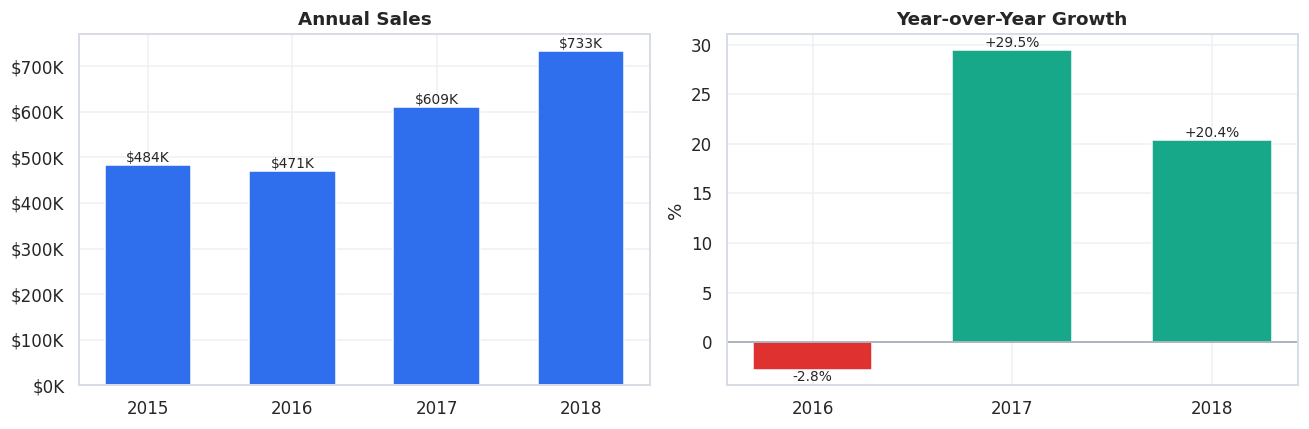

,order_year,sales,profit,orders,yoy,margin
0,2015,"483,966.13","49,556.03",969,NaN,10.24
1,2016,"470,532.51","61,618.60",1038,-2.78,13.10
2,2017,"609,205.60","81,795.17",1315,29.47,13.43
3,2018,"733,215.26","93,439.27",1687,20.36,12.74


In [3]:
yearly = df.groupby("order_year").agg(sales=("sales","sum"), profit=("profit","sum"),
                                      orders=("order_id","nunique")).reset_index()
yearly["yoy"] = yearly.sales.pct_change()*100
yearly["margin"] = yearly.profit/yearly.sales*100

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].bar(yearly.order_year.astype(str), yearly.sales, color=BLUE, width=.6)
ax[0].set_title("Annual Sales"); ax[0].yaxis.set_major_formatter(money)
for x, v in zip(yearly.order_year.astype(str), yearly.sales):
    ax[0].text(x, v, f"${v/1000:,.0f}K", ha="center", va="bottom", fontsize=9)

g = yearly.dropna(subset=["yoy"])
ax[1].bar(g.order_year.astype(str), g.yoy,
          color=[RED if v < 0 else TEAL for v in g.yoy], width=.6)
ax[1].axhline(0, color="#9aa3b2", lw=1)
ax[1].set_title("Year-over-Year Growth"); ax[1].set_ylabel("%")
for x, v in zip(g.order_year.astype(str), g.yoy):
    ax[1].text(x, v, f"{v:+.1f}%", ha="center",
               va="bottom" if v > 0 else "top", fontsize=9)
plt.tight_layout(); plt.savefig(IMAGES / "yearly_growth.png"); plt.show()
yearly

## 2. Three-month forecast

**Method: seasonal naive with a linear trend.** Each future month is predicted as the same
month last year, scaled by the trailing year-over-year growth rate.

Chosen deliberately over ARIMA or Prophet: with only 48 monthly observations and strong
December seasonality, a fitted model has too few complete seasonal cycles to learn from and
tends to produce confident, wrong intervals. A transparent baseline that a business reader
can verify by hand is worth more here than an opaque one — and it is the benchmark any
sophisticated model would have to beat.

In [4]:
s = monthly.set_index("date").sales

# Backtest: hold out the last 6 months, forecast them, measure the error.
train, test = s[:-6], s[-6:]

def seasonal_naive_forecast(series, periods):
    growth = (series[-12:].sum() / series[-24:-12].sum()) if len(series) >= 24 else 1.0
    last_year = series[-12:]
    out, idx = [], []
    for i in range(periods):
        nxt = series.index[-1] + pd.DateOffset(months=i+1)
        out.append(last_year.iloc[i % 12] * growth)
        idx.append(nxt)
    return pd.Series(out, index=idx), growth

pred, growth = seasonal_naive_forecast(train, 6)
mape = (abs(pred.values - test.values) / test.values).mean() * 100
mae = abs(pred.values - test.values).mean()
print(f"Backtest on the last 6 months")
print(f"  Growth factor applied : {growth:.3f}")
print(f"  MAPE                  : {mape:.1f}%")
print(f"  MAE                   : ${mae:,.0f}")

Backtest on the last 6 months
  Growth factor applied : 1.175
  MAPE                  : 18.8%
  MAE                   : $15,325


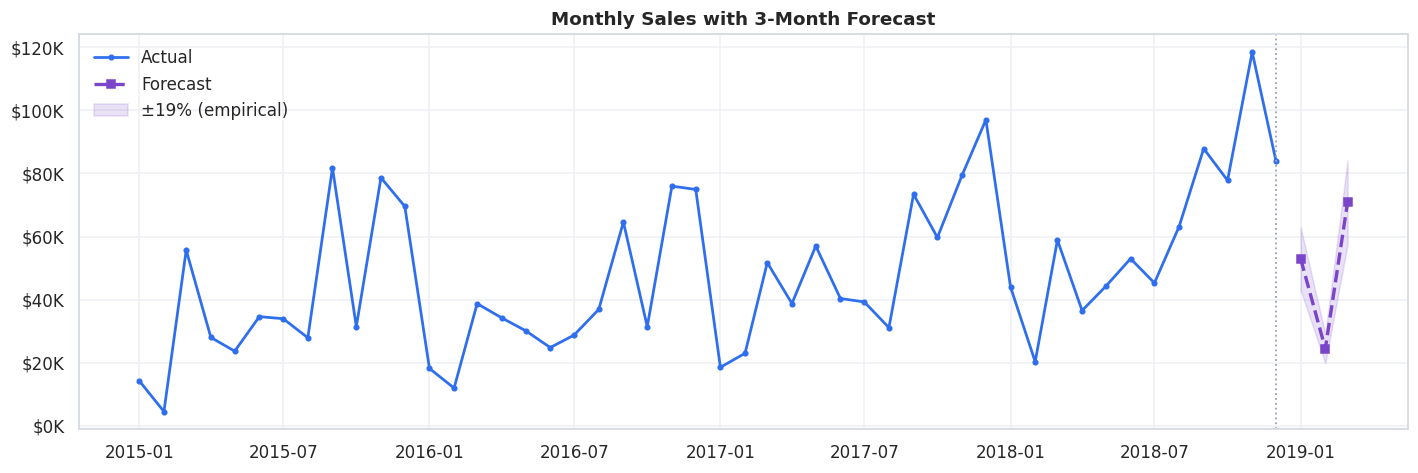

,forecast,lower,upper
2019-01-01,"52,922.00","42,970.00","62,874.00"
2019-02-01,"24,434.00","19,839.00","29,028.00"
2019-03-01,"70,856.00","57,532.00","84,181.00"


In [5]:
forecast, growth = seasonal_naive_forecast(s, 3)

# An empirical interval from historical residuals, not a model assumption.
resid_pct = abs(pred.values - test.values) / test.values
band = resid_pct.mean()
lower, upper = forecast * (1 - band), forecast * (1 + band)

fig, ax = plt.subplots(figsize=(13, 4.4))
ax.plot(s.index, s.values, color=BLUE, lw=1.8, marker="o", ms=3, label="Actual")
ax.plot(forecast.index, forecast.values, color=PURPLE, lw=2.2, ls="--",
        marker="s", ms=5, label="Forecast")
ax.fill_between(forecast.index, lower, upper, color=PURPLE, alpha=.16,
                label=f"±{band*100:.0f}% (empirical)")
ax.axvline(s.index[-1], color="#9aa3b2", ls=":", lw=1.2)
ax.set_title("Monthly Sales with 3-Month Forecast")
ax.yaxis.set_major_formatter(money); ax.legend(frameon=False)
plt.tight_layout(); plt.savefig(IMAGES / "sales_forecast.png"); plt.show()

pd.DataFrame({"forecast": forecast.round(0), "lower": lower.round(0),
              "upper": upper.round(0)})

The backtest MAPE is the number to quote, not the forecast itself. It says how wrong this
method was on months it had not seen — the honest measure of whether the projection is
usable for planning.

## 3. Discount simulation — the what-if

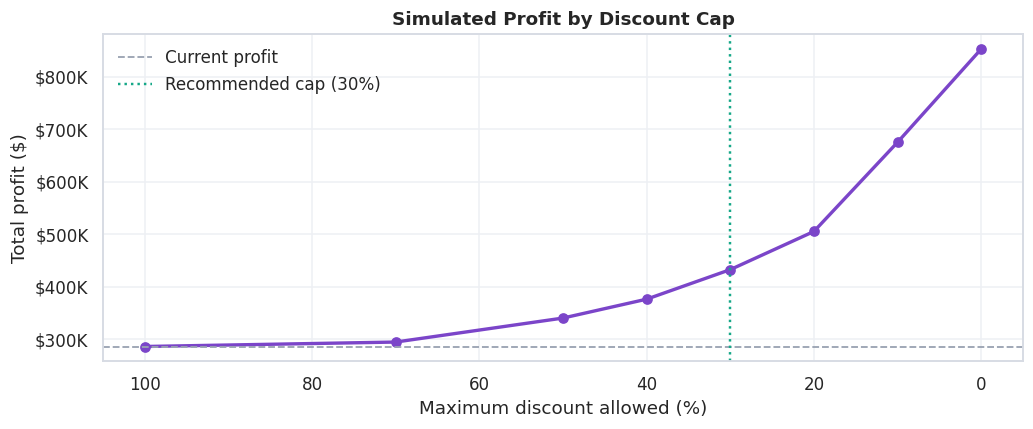

,cap_%,profit,uplift,uplift_%
0,100,"286,409.08",0.00,0.00
1,70,"294,890.96","8,481.88",2.96
2,50,"340,596.08","54,187.00",18.92
3,40,"376,561.57","90,152.49",31.48
4,30,"432,854.93","146,445.85",51.13
5,20,"505,559.88","219,150.80",76.52
6,10,"675,460.21","389,051.13",135.84
7,0,"853,022.67","566,613.59",197.83


In [6]:
# What would profit be if every discount were capped at a given level?
# Assumes the sale still happens at the lower discount, which is optimistic:
# some customers would walk. Treated as an upper bound, not a promise.
def simulate_cap(cap):
    d = df.copy()
    capped = d.discount.clip(upper=cap)
    list_price = np.where(d.discount < 1, d.sales / (1 - d.discount), d.sales)
    new_sales = list_price * (1 - capped)
    # Cost per line is unchanged; profit moves with the recovered revenue.
    return (d.profit + (new_sales - d.sales)).sum()

caps = [1.0, .70, .50, .40, .30, .20, .10, 0.0]
sim = pd.DataFrame({
    "cap_%": [int(c*100) for c in caps],
    "profit": [simulate_cap(c) for c in caps],
})
sim["uplift"] = sim.profit - sim.profit.iloc[0]
sim["uplift_%"] = sim.uplift / sim.profit.iloc[0] * 100

fig, ax = plt.subplots(figsize=(9.5, 4))
ax.plot(sim["cap_%"], sim.profit, color=PURPLE, lw=2.2, marker="o")
ax.axhline(df.profit.sum(), color="#9aa3b2", ls="--", lw=1.2, label="Current profit")
ax.axvline(30, color=TEAL, ls=":", lw=1.6, label="Recommended cap (30%)")
ax.set_title("Simulated Profit by Discount Cap")
ax.set_xlabel("Maximum discount allowed (%)"); ax.set_ylabel("Total profit ($)")
ax.yaxis.set_major_formatter(money); ax.legend(frameon=False); ax.invert_xaxis()
plt.tight_layout(); plt.savefig(IMAGES / "discount_simulation.png"); plt.show()
sim

**The 30% cap is where the curve flattens.** Tightening further returns progressively less
while affecting far more orders — the classic point of diminishing returns, and the reason
the recommendation is 30% rather than "discount less".

Stated as an upper bound: the model assumes every sale still closes at the lower discount.
Some would not. The pilot is what settles it.

## 4. Regional and product views

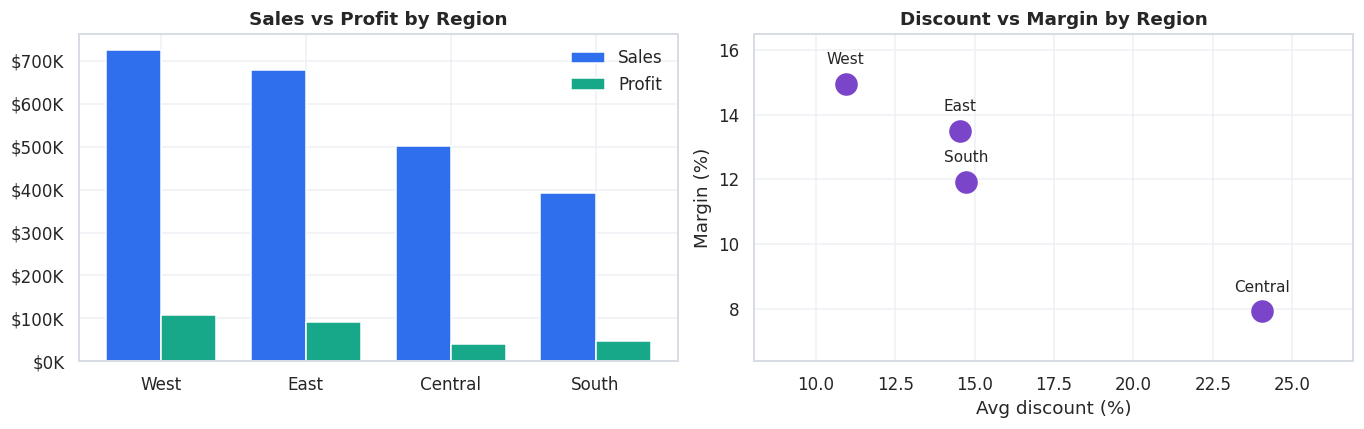

In [7]:
region = (df.groupby("region").agg(sales=("sales","sum"), profit=("profit","sum"),
                                   discount=("discount","mean"))
            .assign(margin=lambda d: d.profit/d.sales*100).sort_values("sales", ascending=False))

fig, ax = plt.subplots(1, 2, figsize=(12.5, 4))
x = np.arange(len(region)); w = .38
ax[0].bar(x-w/2, region.sales, w, label="Sales", color=BLUE)
ax[0].bar(x+w/2, region.profit, w, label="Profit", color=TEAL)
ax[0].set_xticks(x, region.index); ax[0].set_title("Sales vs Profit by Region")
ax[0].yaxis.set_major_formatter(money); ax[0].legend(frameon=False)

ax[1].scatter(region.discount*100, region.margin, s=190, color=PURPLE, zorder=3)
for name, r in region.iterrows():
    ax[1].annotate(name, (r.discount*100, r.margin), textcoords="offset points",
                   xytext=(0,13), ha="center", fontsize=10)
ax[1].set_title("Discount vs Margin by Region")
ax[1].set_xlabel("Avg discount (%)"); ax[1].set_ylabel("Margin (%)"); ax[1].margins(.22)
plt.tight_layout(); plt.savefig(IMAGES / "regional_performance.png"); plt.show()

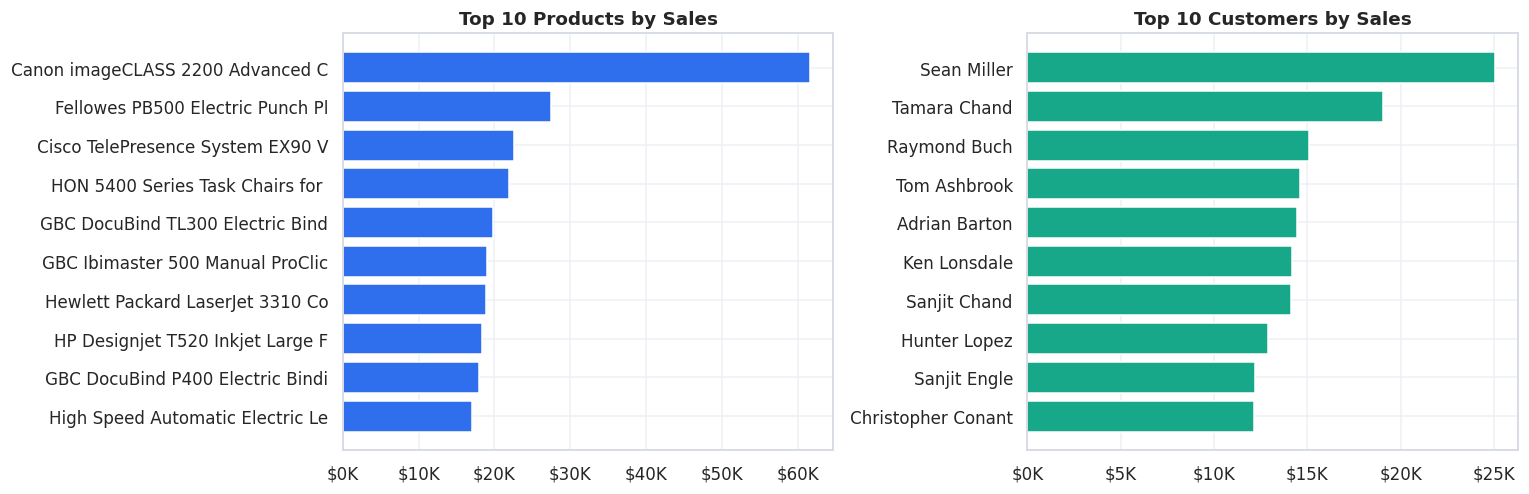

In [8]:
prod = df.groupby("product_name").sales.sum().nlargest(10)
cust = df.groupby("customer_name").sales.sum().nlargest(10)

fig, ax = plt.subplots(1, 2, figsize=(14, 4.6))
ax[0].barh([p[:32] for p in prod.index][::-1], prod.values[::-1], color=BLUE)
ax[0].set_title("Top 10 Products by Sales"); ax[0].xaxis.set_major_formatter(money)
ax[1].barh(cust.index[::-1], cust.values[::-1], color=TEAL)
ax[1].set_title("Top 10 Customers by Sales"); ax[1].xaxis.set_major_formatter(money)
plt.tight_layout(); plt.savefig(IMAGES / "top_products_customers.png"); plt.show()

## 5. Export aggregates for Power BI

In [9]:
out = ROOT / "data" / "processed"
exports = {
    "agg_monthly.csv":     monthly[["year_month","sales","profit"]],
    "agg_yearly.csv":      yearly,
    "agg_region.csv":      region.reset_index(),
    "agg_forecast.csv":    pd.DataFrame({"date": forecast.index, "forecast": forecast.values,
                                         "lower": lower.values, "upper": upper.values}),
    "agg_discount_sim.csv": sim,
}
for name, frame in exports.items():
    frame.to_csv(out / name, index=False)
    print(f"  {name:<24} {len(frame):>4} rows")

  agg_monthly.csv            48 rows
  agg_yearly.csv              4 rows
  agg_region.csv              4 rows
  agg_forecast.csv            3 rows
  agg_discount_sim.csv        8 rows


## Summary

| Finding | Evidence |
|---|---|
| Discounts above 30% destroy $125,007 | 11.7% of lines, margin −24.8% then −119.2% |
| Furniture: 32% of revenue, 2.5% margin | Tables −$17.7K, Bookcases −$3.5K |
| 10 states lose money | All discount 28–40% vs West's 10.9% |
| Philadelphia is 5th by revenue, loses $13.8K | Revenue rank ≠ profit contribution |
| Growth is recent | −2.8% (2016), +29.5% (2017), +20.4% (2018) |
| At Risk = 24.7% of customers, 8.4% of revenue | Avg 329 days since last order |

Every recommendation traces to one of these rows.